# 1.Here look at the overall process:

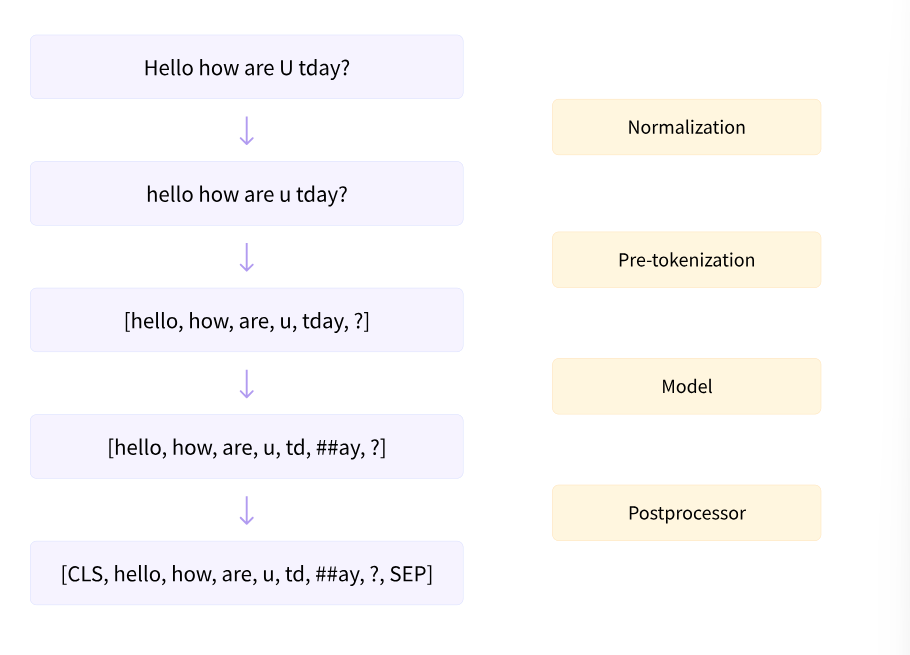

The Tokenizers library has been built to provide several options for each of those steps, which you can mix and match together. In this section we’ll see how we can build a tokenizer from scratch, as opposed to training a new tokenizer from an old one 

More precisely, the library is built around a central Tokenizer class with the building blocks regrouped in submodules:

- normalizers contains all the possible types of Normalizer you can use (complete list here).
- pre_tokenizers contains all the possible types of PreTokenizer you can use (complete list here).
- models contains the various types of Model you can use, like BPE, WordPiece, and Unigram (complete list here).
- trainers contains all the different types of Trainer you can use to train your model on a corpus (one per type of model; complete list here).
- post_processors contains the various types of PostProcessor you can use (complete list here).
- decoders contains the various types of Decoder you can use to decode the outputs of tokenization (complete list here).

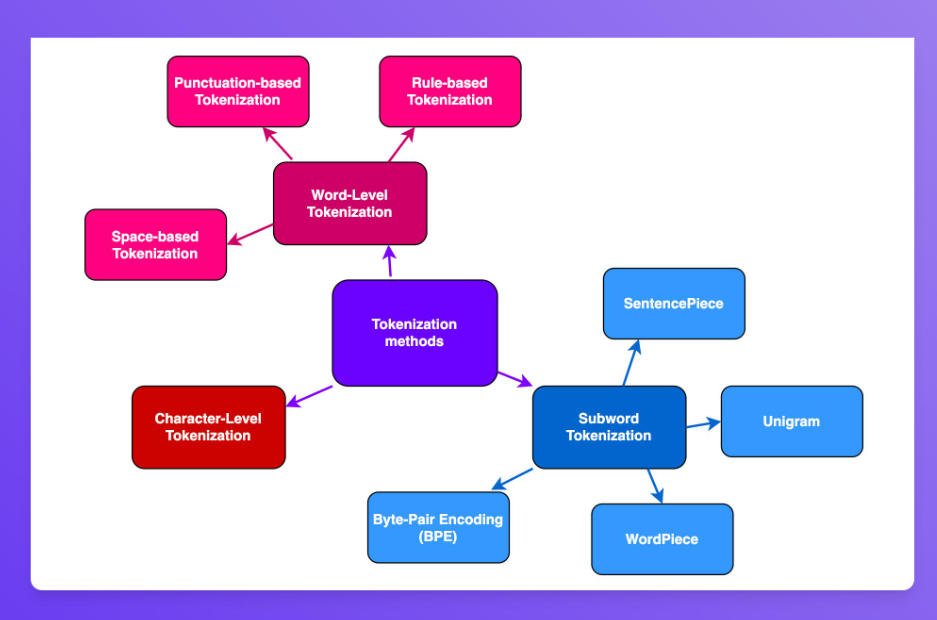

# 2.Acquiring a corpus
To train our new tokenizer, we will use a small corpus of text (so the examples run fast).this time we’ll use the WikiText-2 dataset:

In [2]:
from datasets import load_dataset

dataset = load_dataset('wikitext',name="wikitext-2-raw-v1",split="train")


def get_tranning_corpus():
    for i in range(0,len(dataset),1000):
        yield dataset[i:i+1000]["text"]

The function get_training_corpus() is a generator that will yield batches of 1,000 texts, which we will use to train the tokenizer.

Tokenizers can also be trained on text files directly. Here’s how we can generate a text file containing all the texts/inputs from WikiText-2 that we can use locally:

In [3]:
with open ("wikitext-2.txt","w",encoding = "utf-8") as f:
    for i in range(len(dataset)):
        f.write(dataset[i]["text"] + "\n" )

# 3.Next we’ll show you how to build your own BERT, GPT-2, and XLNet tokenizers, block by block.

That will give us an example of each of the three main tokenization algorithms: WordPiece, BPE, and Unigram.
###  Let’s start with BERT!
    

# 4.Building a WordPiece tokenizer from scratch

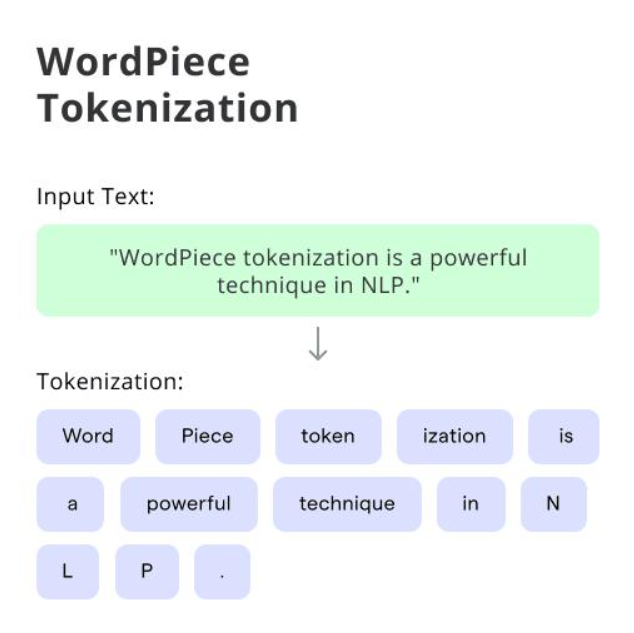

### we’ll create a Tokenizer with a WordPiece model:

In [18]:
from tokenizers import (
    decoders,
    models,
    normalizers,
    pre_tokenizers,
    processors,
    trainers,
    Tokenizer,
)

tokenizer = Tokenizer(models.WordPiece(unk_token = "[UNK]"))

WordPiece = it breaks words into small parts (tokens)

unk_token="[UNK]"
If the tokenizer sees a word it does not know, it will return [UNK]


### Normalization (Cleaning Text)

The first step of tokenization is normalization, so let’s begin with that. Since BERT is widely used, there is a BertNormalizer with the classic options we can set for BERT: lowercase and strip_accents, which are self-explanatory; clean_text to remove all control characters and replace repeating spaces with a single one; and handle_chinese_chars, which places spaces around Chinese characters. To replicate the bert-base-uncased tokenizer, we can just set this normalizer:

In [10]:
tokenizer.normalizer = normalizers.BertNormalizer(lowercase=True)

Normalization = cleaning the text before tokenizing

Here we use BERT normalizer

lowercase=True
Converts all text to small letters

##### What BERT Normalizer Can Do
- lowercase → make text small
- strip_accents → remove accents (é → e)
- clean_text → remove weird characters
- handle_chinese_chars → add space around Chinese chars

### Build Normalizer Manually

So Let’s see how to create the BERT normalizer by hand. The Tokenizers library provides a Lowercase normalizer and a StripAccents normalizer, and you can compose several normalizers using a Sequence:

In [16]:
tokenizer.normalizer = normalizers.Sequence(
    [normalizers.NFD(), normalizers.Lowercase(), normalizers.StripAccents()]
)

We create our own normalizer step by step:

#### Sequence([...])
- Runs all steps one by one

Step-by-step

NFD()
→ splits characters and accents
Example:

é → e + '

Lowercase()
→ makes all text small

HELLO → hello

StripAccents()
→ removes accents

é → e



#### Why NFD is Important?

Without NFD, accents may not be removed properly

So:
- NFD → split
- StripAccents → remove

### Test the Normalizer

In [17]:
print(tokenizer.normalizer.normalize_str("Héllò hôw are ü?"))

hello how are u?


### Pre-tokenization Step

 Again, there is a prebuilt BertPreTokenizer that we can use:

In [19]:
tokenizer.pre_tokenizer = pre_tokenizers.BertPreTokenizer()

- This step splits text into small pieces before real tokenization
- BertPreTokenizer:
  - splits text into words
  - also separates punctuation

### Build Pre-tokenizer Manually

In [24]:
tokenizer.pre_tokenizer.pre_tokenize_str("Let's test my pre-tokenizer.")

[('Let', (0, 3)),
 ("'", (3, 4)),
 ('s', (4, 5)),
 ('test', (6, 10)),
 ('my', (11, 13)),
 ('pre', (14, 17)),
 ('-', (17, 18)),
 ('tokenizer', (18, 27)),
 ('.', (27, 28))]

It splits like this:

- "Let's" → "Let" + "'" + "s"
- "pre-tokenizer" → "pre" + "-" + "tokenizer"

Also shows positions (start, end) in text.

In [25]:
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

- Whitespace splits text by:
  - spaces
  - punctuation

In [26]:
pre_tokenizer = pre_tokenizers.WhitespaceSplit()
pre_tokenizer.pre_tokenize_str("Let's test my pre-tokenizer.")

[("Let's", (0, 5)),
 ('test', (6, 10)),
 ('my', (11, 13)),
 ('pre-tokenizer.', (14, 28))]

Explanation
- Only splits by space
- Does NOT break punctuation

### Combine Multiple Pre-tokenizers

In [27]:
pre_tokenizer = pre_tokenizers.Sequence(
    [pre_tokenizers.WhitespaceSplit(),pre_tokenizers.Punctuation()]
)

Explanation
- First split by space
- Then split punctuation

### Training the Tokenizer (WordPiece)

In [28]:
special_tokens = ["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"]

trainer = trainers.WordPieceTrainer(
    vocab_size = 25000,
    special_tokens=special_tokens
)


Explanation
- vocab_size=25000 → total tokens in vocabulary
- special_tokens → important tokens used in models
Special Tokens Meaning
- [UNK] → unknown word
- [PAD] → padding
- [CLS] → start of sentence
- [SEP] → separator
- [MASK] → used in training

### Train from Data

In [30]:
tokenizer.train_from_iterator(get_tranning_corpus(),trainer = trainer)

Explanation
- Train tokenizer using your dataset

In [31]:
tokenizer

Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"[UNK]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":1, "content":"[PAD]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":2, "content":"[CLS]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":3, "content":"[SEP]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":4, "content":"[MASK]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=WordPiece(unk_token="[UNK]", continuing_subword_prefix="##", max_input_chars_per_word=100, vocab={"[UNK]":0, "[PAD]":1, "[CLS]":2, "[SEP]":3, "[MASK]":4, "!":5, """:6, "#":7, "$":8, "%":9, "&":10, "'":11, "(":12, ")":13, "*":14, "+":15, ",":16, "-":17,

encoding contains:

- tokens → words
- ids → numbers
- attention_mask → important for model
- offsets → position info

### Test the Tokenizer

In [32]:
encoding = tokenizer.encode("I am Sakhawat Hossen")

In [33]:
encoding.tokens

['I', 'am', 'Sak', '##haw', '##at', 'Ho', '##ssen']

### Post-processing (Add Special Tokens)

The last step in the tokenization pipeline is post-processing. We need to add the [CLS] token at the beginning and the [SEP] token at the end (or after each sentence, if we have a pair of sentences). We will use a TemplateProcessor for this, but first we need to know the IDs of the [CLS] and [SEP] tokens in the vocabulary:

In [34]:
cls_token_id = tokenizer.token_to_id("[CLS]")
sep_token_id = tokenizer.token_to_id("[SEP]")
print(cls_token_id, sep_token_id)

2 3


To write the template for the TemplateProcessor, we have to specify how to treat a single sentence and a pair of sentences. For both, we write the special tokens we want to use; the first (or single) sentence is represented by $A, while the second sentence (if encoding a pair) is represented by $B. For each of these (special tokens and sentences), we also specify the corresponding token type ID after a colon.

The classic BERT template is thus defined as follows:

In [35]:
tokenizer.post_processor = processors.TemplateProcessing(
    single=f"[CLS]:0 $A:0 [SEP]:0",
    pair=f"[CLS]:0 $A:0 [SEP]:0 $B:1 [SEP]:1",
    special_tokens=[("[CLS]", cls_token_id), ("[SEP]", sep_token_id)],
)

Note that we need to pass along the IDs of the special tokens, so the tokenizer can properly convert them to their IDs.

Once this is added, going back to our previous example will give:

In [36]:
encoding = tokenizer.encode("Let's test this tokenizer.")
print(encoding.tokens)

['[CLS]', 'Let', "'", 's', 'test', 'this', 'to', '##ken', '##izer', '.', '[SEP]']


And on a pair of sentences, we get the proper result:

In [38]:
encoding = tokenizer.encode("Let's test this tokenizer...", "on a pair of sentences.")
print(encoding.tokens)
print(encoding.type_ids)

['[CLS]', 'Let', "'", 's', 'test', 'this', 'to', '##ken', '##izer', '...', '[SEP]', 'on', 'a', 'pair', 'of', 'sentences', '.', '[SEP]']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]


We’ve almost finished building this tokenizer from scratch — the last step is to include a decoder:



In [39]:
tokenizer.decoder = decoders.WordPiece(prefix="##")

In [40]:
tokenizer

Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"[UNK]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":1, "content":"[PAD]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":2, "content":"[CLS]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":3, "content":"[SEP]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":4, "content":"[MASK]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}], normalizer=None, pre_tokenizer=Whitespace(), post_processor=TemplateProcessing(single=[SpecialToken(id="[CLS]", type_id=0), Sequence(id=A, type_id=0), SpecialToken(id="[SEP]", type_id=0)], pair=[SpecialToken(id="[CLS]", type_id=0), Sequence(id=A, type_id=0), SpecialToken(id="[SEP]", type_id=0), Sequence(id=B, type_id=1), SpecialToken(id

Let’s test it on our previous encoding:

In [42]:
tokenizer.decode(encoding.ids)

"Let ' s test this tokenizer... on a pair of sentences."

Great! We can save our tokenizer in a single JSON file like this:

In [43]:
tokenizer.save("tokenizer.json")

We can then reload that file in a Tokenizer object with the from_file() method:

In [44]:
new_tokenizer = Tokenizer.from_file("tokenizer.json")

To use this tokenizer in Transformers, we have to wrap it in a PreTrainedTokenizerFast. We can either use the generic class or, if our tokenizer corresponds to an existing model, use that class (here, BertTokenizerFast). If you apply this lesson to build a brand new tokenizer, you will have to use the first option.

To wrap the tokenizer in a PreTrainedTokenizerFast, we can either pass the tokenizer we built as a tokenizer_object or pass the tokenizer file we saved as tokenizer_file. The key thing to remember is that we have to manually set all the special tokens, since that class can’t infer from the tokenizer object which token is the mask token, the [CLS] token, etc.:

In [45]:
from transformers import PreTrainedTokenizerFast

wrapped_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    # tokenizer_file="tokenizer.json", # You can load from the tokenizer file, alternatively
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]",
)

If you are using a specific tokenizer class (like BertTokenizerFast), you will only need to specify the special tokens that are different from the default ones (here, none):

In [ ]:
from transformers import BertTokenizerFast

wrapped_tokenizer = BertTokenizerFast(tokenizer_object=tokenizer)

You can then use this tokenizer like any other Transformers tokenizer. You can save it with the save_pretrained() method, or upload it to the Hub with the push_to_hub() method.

Now that we’ve seen how to build a WordPiece tokenizer, let’s do the same for a BPE tokenizer. We’ll go a bit faster since you know all the steps, and only highlight the differences.

# Building a BPE tokenizer from scratch

Let’s now build a GPT-2 tokenizer. Like for the BERT tokenizer, we start by initializing a Tokenizer with a BPE model:

### Create BPE Tokenizer (GPT-2 Style)

In [47]:
tokenizer = Tokenizer(models.BPE())

Easy Explanation
- We create a tokenizer using BPE (Byte Pair Encoding)
- This is the method used in GPT-2

Important Idea
- BPE splits words into frequent sub-parts
- It learns from data automatically

**Note**
- We don’t give vocabulary now

    → because we will train it

- No [UNK] token needed

    → GPT-2 uses byte-level encoding, so it can handle any text

### No Normalization Step

Explanation
- GPT-2 does not clean or modify text
- So we skip normalization

### Pre-tokenization (ByteLevel)

In [49]:
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space = False)

Easy Explanation
- Splits text into byte-level tokens
- Keeps spaces as part of tokens

Parameter
- add_prefix_space=False
- does NOT add space at beginning

Example

In [51]:
tokenizer.pre_tokenizer.pre_tokenize_str("hi i am sahen")

[('hi', (0, 2)), ('Ġi', (2, 4)), ('Ġam', (4, 7)), ('Ġsahen', (7, 13))]

Important Concept: "Ġ"

Ġ means space before word

### Train the BPE Model

In [55]:
trainer = trainers.BpeTrainer(
    vocab_size=25000, 
    special_tokens=["<|endoftext|>"]
)

tokenizer.train_from_iterator(get_tranning_corpus(), trainer=trainer)

Easy Explanation
- vocab_size=25000 → number of tokens
- <|endoftext|> → special token (used by GPT-2)

### Train from File

In [56]:
tokenizer.model=models.BPE()
tokenizer.train(["wikitext-2.txt"],trainer=trainer)

### Test Tokenization

In [57]:
encoding = tokenizer.encode("i am sakhawat hossen")
print(encoding.tokens)

['i', 'Ġam', 'Ġs', 'ak', 'haw', 'at', 'Ġh', 'oss', 'en']


### Post-processing

In [58]:
tokenizer.post_processor = processors.ByteLevel(trim_offsets=False)

Explanation
- Keeps track of positions in original text
- Does NOT remove spaces from offsets

In [59]:
sentence = "Let's test this tokenizer."
encoding = tokenizer.encode(sentence)

start, end = encoding.offsets[4]
sentence[start:end]

' test'

### Decoder (Convert Back to Text)

In [61]:
tokenizer.decoder = decoders.ByteLevel()

In [62]:
tokenizer.decode(encoding.ids)

"Let's test this tokenizer."

### Save Tokenizer

In [64]:
tokenizer.save("tokenizer.json")

### Use in Transformers

In [65]:
from transformers import PreTrainedTokenizerFast

wrapped_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    bos_token="<|endoftext|>",
    eos_token="<|endoftext|>",
)

Explanation
- bos_token = beginning of sentence
- eos_token = end of sentence

GPT-2 uses same token for both

### GPT-2 Specific

In [67]:
from transformers import GPT2TokenizerFast

wrapped_tokenizer = GPT2TokenizerFast(tokenizer_object=tokenizer)

Explanation
- Easier version for GPT-2
- Default settings already included

# Building a Unigram tokenizer from scratch

Let’s now build an XLNet tokenizer. Like for the previous tokenizers, we start by initializing a Tokenizer with a Unigram model:

In [68]:
tokenizer = Tokenizer(models.Unigram())

Again, we could initialize this model with a vocabulary if we had one.

For the normalization, XLNet uses a few replacements (which come from SentencePiece):

In [69]:
from tokenizers import Regex

tokenizer.normalizer = normalizers.Sequence(
    [
        normalizers.Replace("``", '"'),
        normalizers.Replace("''", '"'),
        normalizers.NFKD(),
        normalizers.StripAccents(),
        normalizers.Replace(Regex(" {2,}"), " "),
    ]
)

This replaces “ and ” with ” and any sequence of two or more spaces with a single space, as well as removing the accents in the texts to tokenize.

The pre-tokenizer to use for any SentencePiece tokenizer is Metaspace:

In [70]:
tokenizer.pre_tokenizer = pre_tokenizers.Metaspace()

We can have a look at the pre-tokenization of an example text like before:

In [71]:
tokenizer.pre_tokenizer.pre_tokenize_str("Let's test the pre-tokenizer!")

[("▁Let's", (0, 5)),
 ('▁test', (5, 10)),
 ('▁the', (10, 14)),
 ('▁pre-tokenizer!', (14, 29))]

Next is the model, which needs training. XLNet has quite a few special tokens:

In [76]:
special_tokens = ["<cls>", "<sep>", "<unk>", "<pad>", "<mask>", "<s>", "</s>"]
trainer = trainers.UnigramTrainer(
    vocab_size=25000, special_tokens=special_tokens, unk_token="<unk>"
)
tokenizer.train_from_iterator(get_tranning_corpus(), trainer=trainer)

A very important argument not to forget for the UnigramTrainer is the unk_token. We can also pass along other arguments specific to the Unigram algorithm, such as the shrinking_factor for each step where we remove tokens (defaults to 0.75) or the max_piece_length to specify the maximum length of a given token (defaults to 16).

This tokenizer can also be trained on text files:

In [77]:
tokenizer.model = models.Unigram()
tokenizer.train(["wikitext-2.txt"], trainer=trainer)

Let’s have a look at the tokenization of a sample text:

In [78]:
encoding = tokenizer.encode("Let's test this tokenizer.")
print(encoding.tokens)

['▁Let', "'", 's', '▁test', '▁this', '▁to', 'ken', 'izer', '.']


A peculiarity of XLNet is that it puts the <cls> token at the end of the sentence, with a type ID of 2 (to distinguish it from the other tokens). It’s padding on the left, as a result. We can deal with all the special tokens and token type IDs with a template, like for BERT, but first we have to get the IDs of the <cls> and <sep> tokens:

In [81]:
cls_token_id = tokenizer.token_to_id("<cls>")
sep_token_id = tokenizer.token_to_id("<sep>")
print(cls_token_id, sep_token_id)

0 1


In [82]:
tokenizer.post_processor = processors.TemplateProcessing(
    single="$A:0 <sep>:0 <cls>:2",
    pair="$A:0 <sep>:0 $B:1 <sep>:1 <cls>:2",
    special_tokens=[("<sep>", sep_token_id), ("<cls>", cls_token_id)],
)

And we can test it works by encoding a pair of sentences:

In [83]:
encoding = tokenizer.encode("Let's test this tokenizer...", "on a pair of sentences!")
print(encoding.tokens)
print(encoding.type_ids)

['▁Let', "'", 's', '▁test', '▁this', '▁to', 'ken', 'izer', '.', '.', '.', '<sep>', '▁', 'on', '▁', 'a', '▁pair', '▁of', '▁sentence', 's', '!', '<sep>', '<cls>']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2]


Finally, we add a Metaspace decoder:

In [84]:
tokenizer.decoder = decoders.Metaspace()

and we’re done with this tokenizer! We can save the tokenizer like before, and wrap it in a PreTrainedTokenizerFast or XLNetTokenizerFast if we want to use it in Transformers. One thing to note when using PreTrainedTokenizerFast is that on top of the special tokens, we need to tell the Transformers library to pad on the left:

In [85]:
from transformers import PreTrainedTokenizerFast

wrapped_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    bos_token="<s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
    cls_token="<cls>",
    sep_token="<sep>",
    mask_token="<mask>",
    padding_side="left",
)

Or alternatively:

In [87]:
from transformers import XLNetTokenizerFast

wrapped_tokenizer = XLNetTokenizerFast(tokenizer_object=tokenizer)

Thank You

Thank you for taking the time to go through this notebook. I hope you found it helpful and informative.

If you liked this work, please consider giving it an upvote. Your support motivates me to create more useful content.

You can also connect with me and explore more of my work here:

- Full Github Repo : https://github.com/Sakhawathossen04/Building-LLMs-from-scratch-In-Bangla
- GitHub: https://github.com/Sakhawathossen04
- LinkedIn: https://www.linkedin.com/in/sakhawathossenofficial/
- Kaggle : https://www.kaggle.com/sakhawathossen

Feel free to share your feedback or suggestions. Your input is always appreciated.